In [1]:
import pandas as pd

df = pd.read_csv('Telco-Customer-Churn.csv')
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [2]:
print(df.shape)

(7043, 21)


In [3]:
print(df.dtypes)


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# Fix TotalCharges from text to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check if any nulls appeared after fixing
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [6]:
# Drop rows where TotalCharges is null
df = df.dropna(subset=['TotalCharges'])

# Confirm
print(df.shape)
print(df.isnull().sum().sum())

(7032, 21)
0


In [7]:
# Convert Churn from Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Check result
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


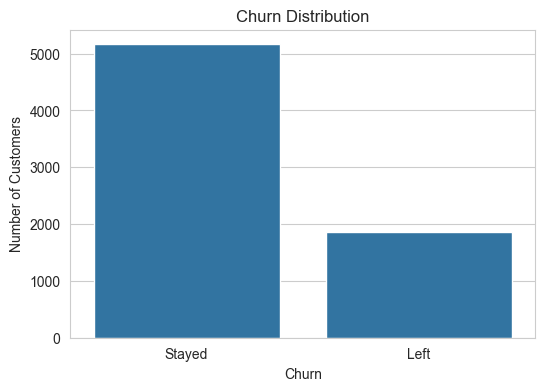

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')

# Plot Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.xticks([0,1], ['Stayed', 'Left'])
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

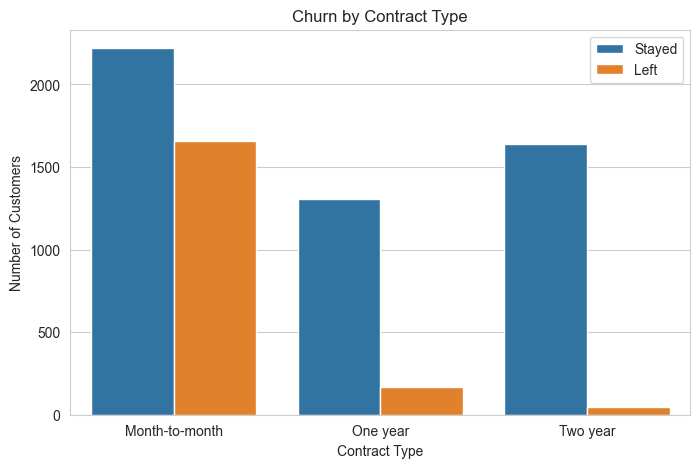

In [9]:
# Churn by Contract Type
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Left'])
plt.show()


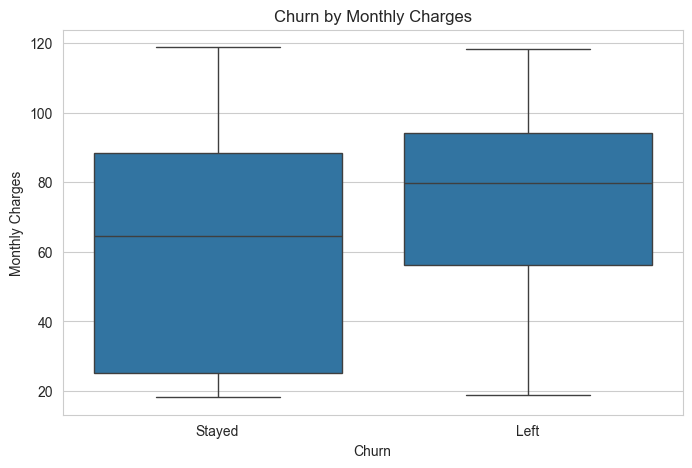

In [10]:
# Churn by Monthly Charges
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Churn by Monthly Charges')
plt.xticks([0,1], ['Stayed', 'Left'])
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

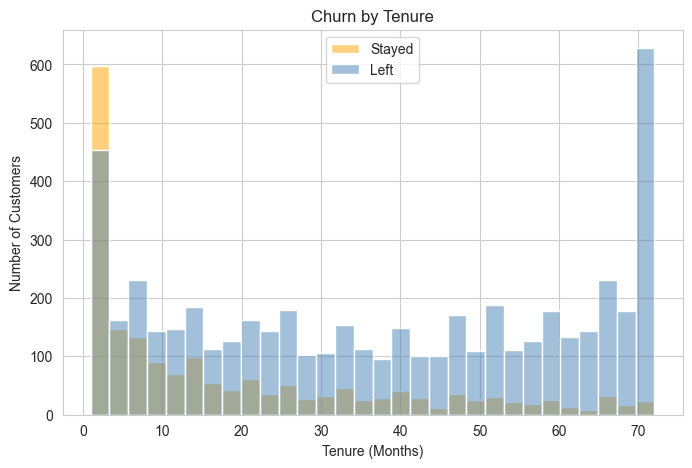

In [11]:
# Churn by Tenure (Fixed)
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
            palette={0:'steelblue', 1:'orange'})
plt.title('Churn by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Left'])
plt.show()

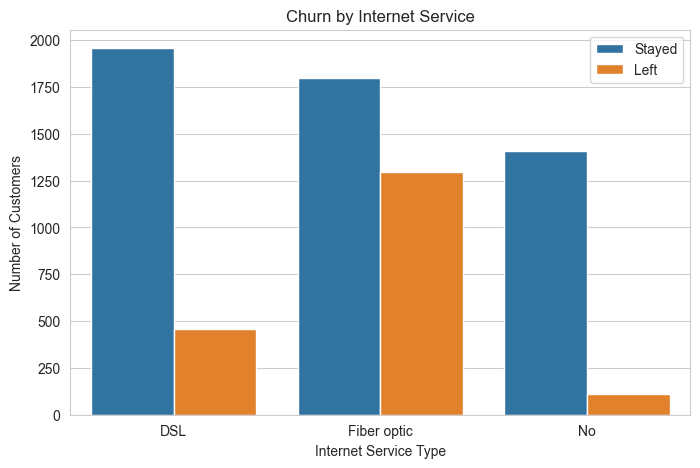

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Left'])
plt.show()

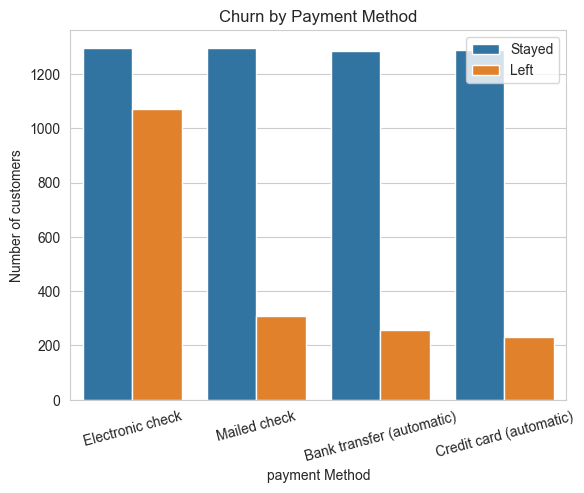

In [13]:
plt.Figure(figsize=(8,5))
sns.countplot(x='PaymentMethod' , hue='Churn' , data=df)
plt.title('Churn by Payment Method')
plt.xlabel('payment Method')
plt.ylabel('Number of customers')
plt.xticks(rotation=15)
plt.legend(['Stayed','Left'])
plt.show()

In [14]:
df.to_csv('telco_churn_cleaned.csv', index=False)
print("File saved successfully!")

File saved successfully!
